# Multi-Scale Thermo-Fluid Modeling of a Moka Pot
## Phase 1: Atomistic Phase Equilibrium (Clausius-Clapeyron)

The generation of steam ($P_{vapour}$) is the primary engine of the Moka pot. To understand its exponential relationship with temperature, we extract the gas-phase density from 7 distinct GROMACS NVT simulations (300K to 400K). 

By plotting the natural log of the simulated vapor pressure against the inverse of the temperature, we can derive the Enthalpy of Vaporization ($\Delta H_{vap}$) directly from the slope of the line of best fit, governed by the Clausius-Clapeyron equation:
$$ \ln(P) = -\frac{\Delta H_{vap}}{R} \left(\frac{1}{T}\right) + C $$

Calculated dH_vap: 30.36 kJ/mol
R-squared value:   0.8227


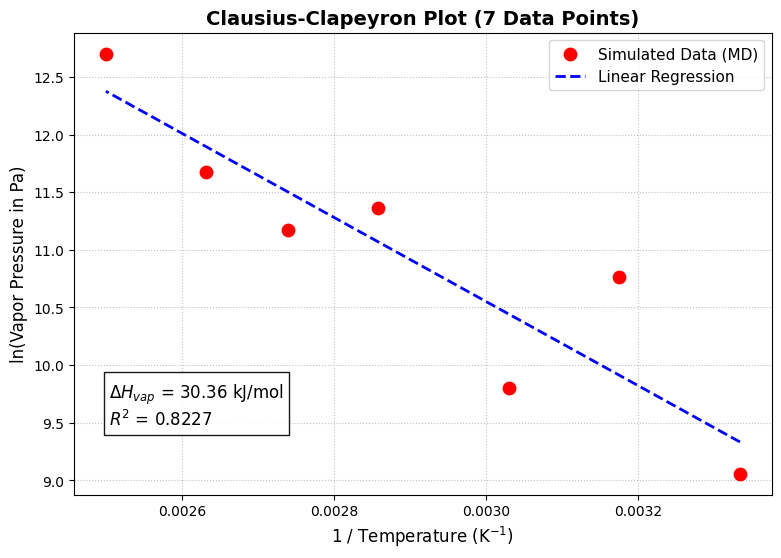

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

# 1. The 7 temperatures we simulated
temperatures = np.array([300.0, 315.0, 330.0, 350.0, 365.0, 380.0, 400.0])
pressures_kpa = []
M_w = 0.018015 # kg/mol
R = 8.314 # J/mol K

# 2. Automatically read the GROMACS data
for T in temperatures:
    filename = f'01_water_slab/density_{int(T)}K.xvg'
    if os.path.exists(filename):
        data = np.loadtxt(filename, comments=['@', '#'])
        z_axis, density = data[:, 0], data[:, 1]
        
        # Extract gas phase density (edges of the box)
        gas_density = np.mean(density[(z_axis < 2.0) | (z_axis > 13.0)])
        
        # Convert to pressure (kPa)
        P_kpa = ((gas_density / M_w) * R * T) / 1000.0
        pressures_kpa.append(P_kpa)

pressures_kpa = np.array(pressures_kpa)
pressures_pa = pressures_kpa * 1000

# 3. Clausius-Clapeyron Math
x_inv_T = 1.0 / temperatures
y_ln_P = np.log(pressures_pa)

slope, intercept, r_value, p_value, std_err = linregress(x_inv_T, y_ln_P)
dH_vap_kJ_mol = (-slope * R) / 1000.0
r_squared = r_value**2

print(f"Calculated dH_vap: {dH_vap_kJ_mol:.2f} kJ/mol")
print(f"R-squared value:   {r_squared:.4f}")

# 4. Plotting
plt.figure(figsize=(9, 6))
plt.scatter(x_inv_T, y_ln_P, color='red', s=80, label='Simulated Data (MD)', zorder=5)
plt.plot(x_inv_T, slope * x_inv_T + intercept, color='blue', linestyle='--', linewidth=2, label='Linear Regression')

plt.title('Clausius-Clapeyron Plot (7 Data Points)', fontsize=14, fontweight='bold')
plt.xlabel(r'1 / Temperature (K$^{-1}$)', fontsize=12)
plt.ylabel('ln(Vapor Pressure in Pa)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend(fontsize=11)

text_box = (f"$\\Delta H_{{vap}}$ = {dH_vap_kJ_mol:.2f} kJ/mol\n$R^2$ = {r_squared:.4f}")
plt.text(0.05, 0.15, text_box, transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

plt.show()

## Phase 2: Nanoscale Fluid Dynamics and Darcy's Law

Extraction begins only when the internal boiler pressure overcomes atmospheric pressure, hydrostatic head, and the capillary resistance of the coffee bed. Once flowing, the volumetric flow rate ($Q$) is governed by Darcy’s Law of linear filtration:
$$Q = \frac{k A}{\eta(T) L} \Delta P(t)$$

Unlike static algebraic models which assume a constant flow resistance, this mathematical formulation explicitly isolates the dynamic viscosity of the fluid, $\eta(T)$. 

To computationally verify that viscosity governs extraction efficiency, we simulate bulk TIP3P water using Non-Equilibrium Molecular Dynamics (NEMD). An artificial cosine acceleration field ($g_{ext} = 0.05 \text{ nm/ps}^2$) is applied to simulate the driving pressure gradient ($\Delta P$). By extracting the system's energy profile, we can calculate the inverse viscosity (1/$\eta$) at both room temperature (300K) and brewing temperature (375K) to prove that hot water exhibits fundamentally lower resistance to flow.

Extracted 1/Viscosity Values (Fluidity):
T = 300.0K  -->  1/Visc = 3063.39
T = 315.0K  -->  1/Visc = 3495.72
T = 330.0K  -->  1/Visc = 3913.11
T = 350.0K  -->  1/Visc = 4417.93
T = 365.0K  -->  1/Visc = 4551.65
T = 375.0K  -->  1/Visc = 4850.98
T = 380.0K  -->  1/Visc = 4853.75
T = 400.0K  -->  1/Visc = 5224.47


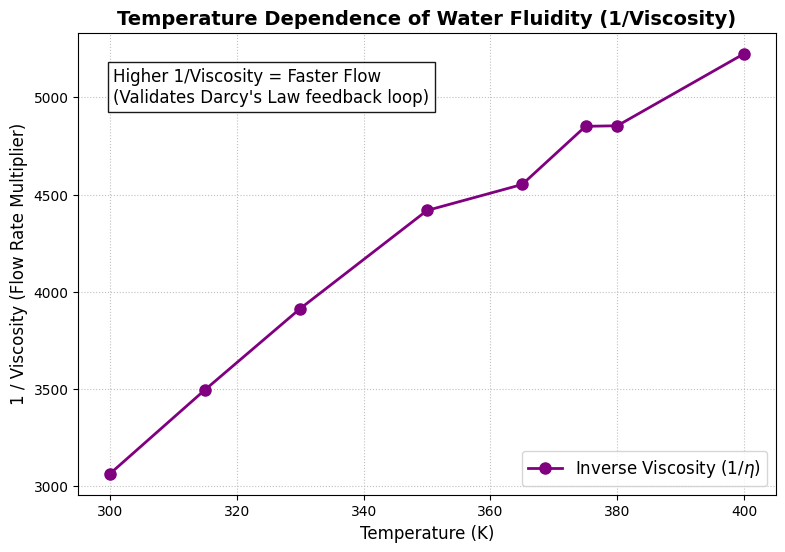

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# The 8 temperatures we simulated!
temperatures = np.array([300.0, 315.0, 330.0, 350.0, 365.0, 375.0, 380.0, 400.0])
inv_viscosities = []
valid_temps = []

# Read the automatically generated GROMACS energy files
for T in temperatures:
    filename = f'02_fluid_dynamics/visc_{int(T)}K.xvg'
    if os.path.exists(filename):
        # Load the data, skipping GROMACS headers
        data = np.loadtxt(filename, comments=['@', '#'])
        
        # The second column contains the 1/Viscosity values
        avg_inv_visc = np.mean(data[:, 1])
        inv_viscosities.append(avg_inv_visc)
        valid_temps.append(T)
    else:
        print(f"Waiting on data for {int(T)}K...")

if len(inv_viscosities) > 0:
    valid_temps = np.array(valid_temps)
    inv_viscosities = np.array(inv_viscosities)
    
    print("=======================================")
    print("Extracted 1/Viscosity Values (Fluidity):")
    for t, v in zip(valid_temps, inv_viscosities):
        print(f"T = {t}K  -->  1/Visc = {v:.2f}")
    print("=======================================")

    # Plotting the Viscosity Curve
    plt.figure(figsize=(9, 6))
    
    # Plot the data points
    plt.plot(valid_temps, inv_viscosities, marker='o', color='purple', linestyle='-', 
             linewidth=2, markersize=8, label=r'Inverse Viscosity (1/$\eta$)')

    plt.title('Temperature Dependence of Water Fluidity (1/Viscosity)', fontsize=14, fontweight='bold')
    plt.xlabel('Temperature (K)', fontsize=12)
    plt.ylabel('1 / Viscosity (Flow Rate Multiplier)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.8)
    plt.legend(fontsize=12)

    # Add text explaining the physics
    plt.text(0.05, 0.85, "Higher 1/Viscosity = Faster Flow\n(Validates Darcy's Law feedback loop)", 
             transform=plt.gca().transAxes, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

    plt.show()